In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import RobustScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import time
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Data Loading

In [26]:
try:
    df = pd.read_csv('creditcard.csv')
    print("File 'creditcard.csv' loaded successfully.")
    print("DataFrame dimensions:", df.shape)
    print("\nFirst lines of the DataFrame:")
    print(df.head())
except FileNotFoundError:
    print("ERROR: The file 'creditcard.csv' was not found.")
    print("Please check that the file is in the correct directory and run the script again.")
    exit()

File 'creditcard.csv' loaded successfully.
DataFrame dimensions: (284807, 31)

First lines of the DataFrame:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0

# Exploratory Data Analysis and Data Preprocessing


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

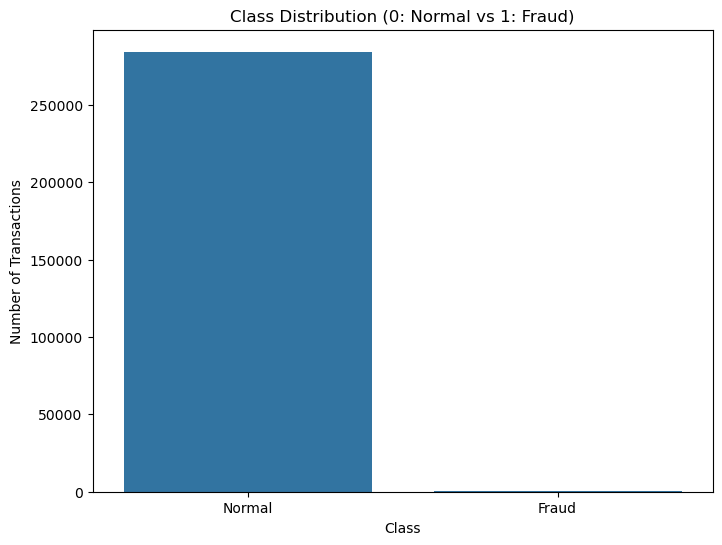


--- Analysis of 'Time' and 'Amount' variables ---


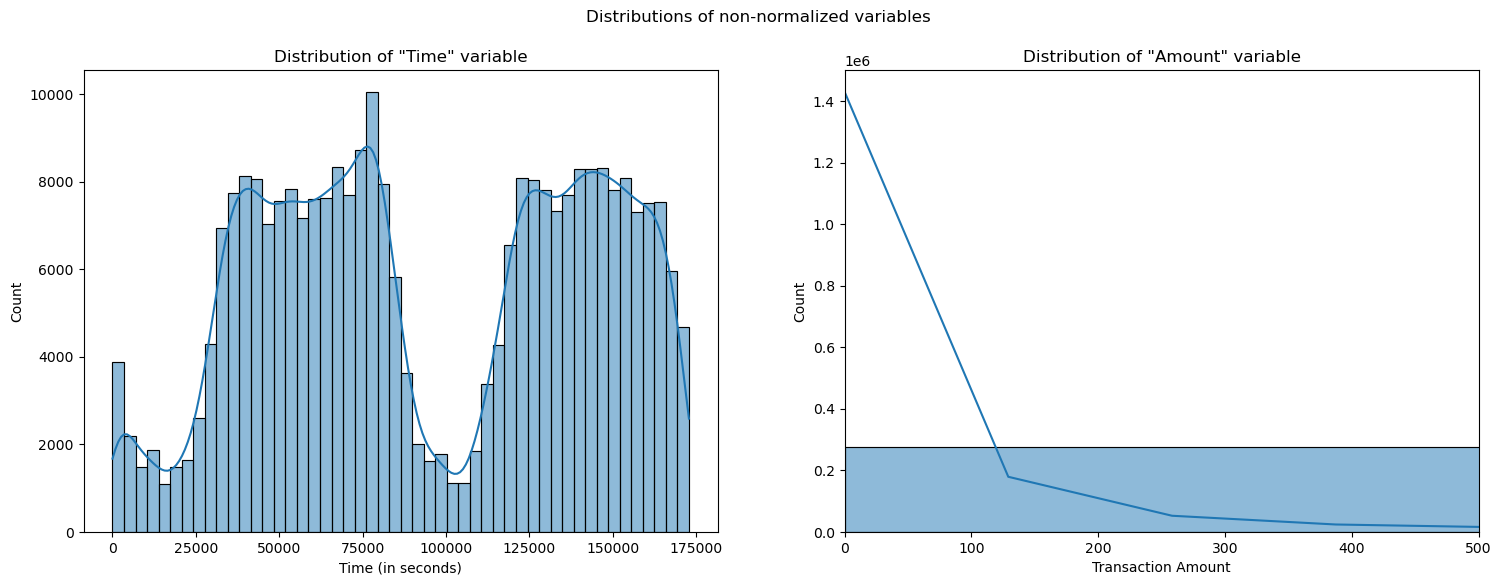


--- Data Preprocessing ---
DataFrame after normalization and reorganization:
   scaled_time  scaled_amount        V1        V2        V3        V4  \
0    -0.994983       1.783274 -1.359807 -0.072781  2.536347  1.378155   
1    -0.994983      -0.269825  1.191857  0.266151  0.166480  0.448154   
2    -0.994972       4.983721 -1.358354 -1.340163  1.773209  0.379780   
3    -0.994972       1.418291 -0.966272 -0.185226  1.792993 -0.863291   
4    -0.994960       0.670579 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V22       V23       V24  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.277838 -0.110474  0.066928   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.638672  0.101288 -0.339846   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.771679  0.909412 -0.689281   
3 -0.010309  1.247203  0.237609  0.377436  ...  0.005274 -0.190321 -1.175575   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.798278 -0.137458  0.141267   

  

In [27]:
print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\n--- Class Imbalance Analysis ---")
class_counts = df['Class'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nPercentage of fraudulent transactions: {class_counts[1] / (class_counts[0] + class_counts[1]) * 100:.4f}%")

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal vs 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.show()

print("\n--- Analysis of 'Time' and 'Amount' variables ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Time'], bins=50, kde=True, ax=ax1)
ax1.set_title('Distribution of "Time" variable')
ax1.set_xlabel('Time (in seconds)')

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax2)
ax2.set_title('Distribution of "Amount" variable')
ax2.set_xlabel('Transaction Amount')
ax2.set_xlim(0, 500) 

plt.suptitle('Distributions of non-normalized variables')
plt.show()

print("\n--- Data Preprocessing ---")

scaler = RobustScaler()
df_processed = df.copy()

df_processed['scaled_amount'] = scaler.fit_transform(df_processed['Amount'].values.reshape(-1, 1))
df_processed['scaled_time'] = scaler.fit_transform(df_processed['Time'].values.reshape(-1, 1))

df_processed.drop(['Time', 'Amount'], axis=1, inplace=True)

cols = list(df_processed.columns)
cols.remove('Class')
df_processed = df_processed[['scaled_time', 'scaled_amount'] + cols + ['Class']]

print("DataFrame after normalization and reorganization:")
print(df_processed.head())

- The chart shows a very large bar for “Normal” transactions and an almost invisible bar for “Fraud” transactions.
- The histogram has two main peaks (it is bimodal). There are periods of high activity and periods of low activity.
- The original columns Time and Amount have disappeared. They have been replaced by scaled_time and scaled_amount, whose values are now small numbers (e.g., -0.99, 1.78, 4.98).
- The percentage of fraud cases is almost identical in the training set (0.1729%) and the test set (0.1720%).

In [28]:
print("\n--- Splitting Data into Training and Test Sets ---")

X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of the training set (X_train):", X_train.shape)
print("Shape of the test set (X_test):", X_test.shape)

print("\nProportion of frauds in the original set: {:.4f}%".format(y.mean() * 100))
print("Proportion of frauds in the training set: {:.4f}%".format(y_train.mean() * 100))
print("Proportion of frauds in the test set: {:.4f}%".format(y_test.mean() * 100))
print("\nStratification was successful.")


--- Splitting Data into Training and Test Sets ---
Shape of the training set (X_train): (227845, 32)
Shape of the test set (X_test): (56962, 32)

Proportion of frauds in the original set: 0.1727%
Proportion of frauds in the training set: 0.1729%
Proportion of frauds in the test set: 0.1720%

Stratification was successful.


--- 1. Correlation Analysis ---


C:\Users\zargu\AppData\Local\Temp\ipykernel_76692\3723231623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_class.values, y=corr_class.index, palette='vlag')


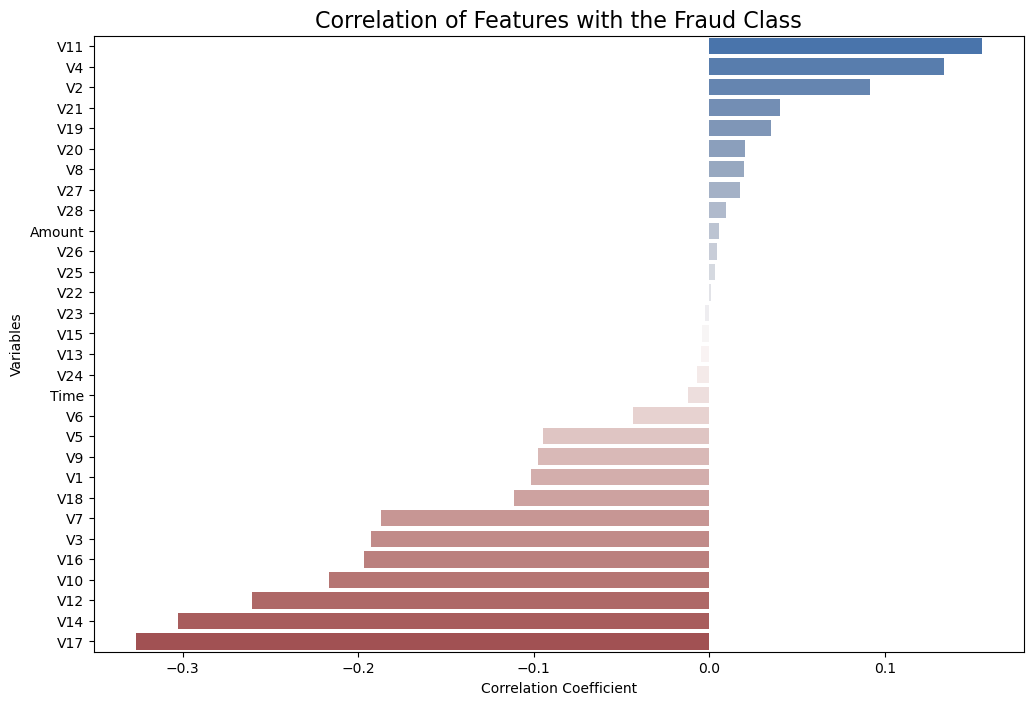

Top 5 positive correlations with fraud:
 V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top 5 negative correlations with fraud:
 V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

--- 2. Distribution of Key Features by Class ---


C:\Users\zargu\AppData\Local\Temp\ipykernel_76692\3723231623.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(['Normal (0)', 'Fraud (1)'])
C:\Users\zargu\AppData\Local\Temp\ipykernel_76692\3723231623.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(['Normal (0)', 'Fraud (1)'])
C:\Users\zargu\AppData\Local\Temp\ipykernel_76692\3723231623.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabels(['Normal (0)', 'Fraud (1)'])
C:\Users\zargu\AppData\Local\Temp\ipykernel_76692\3723231623.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row, col].set_xticklabe

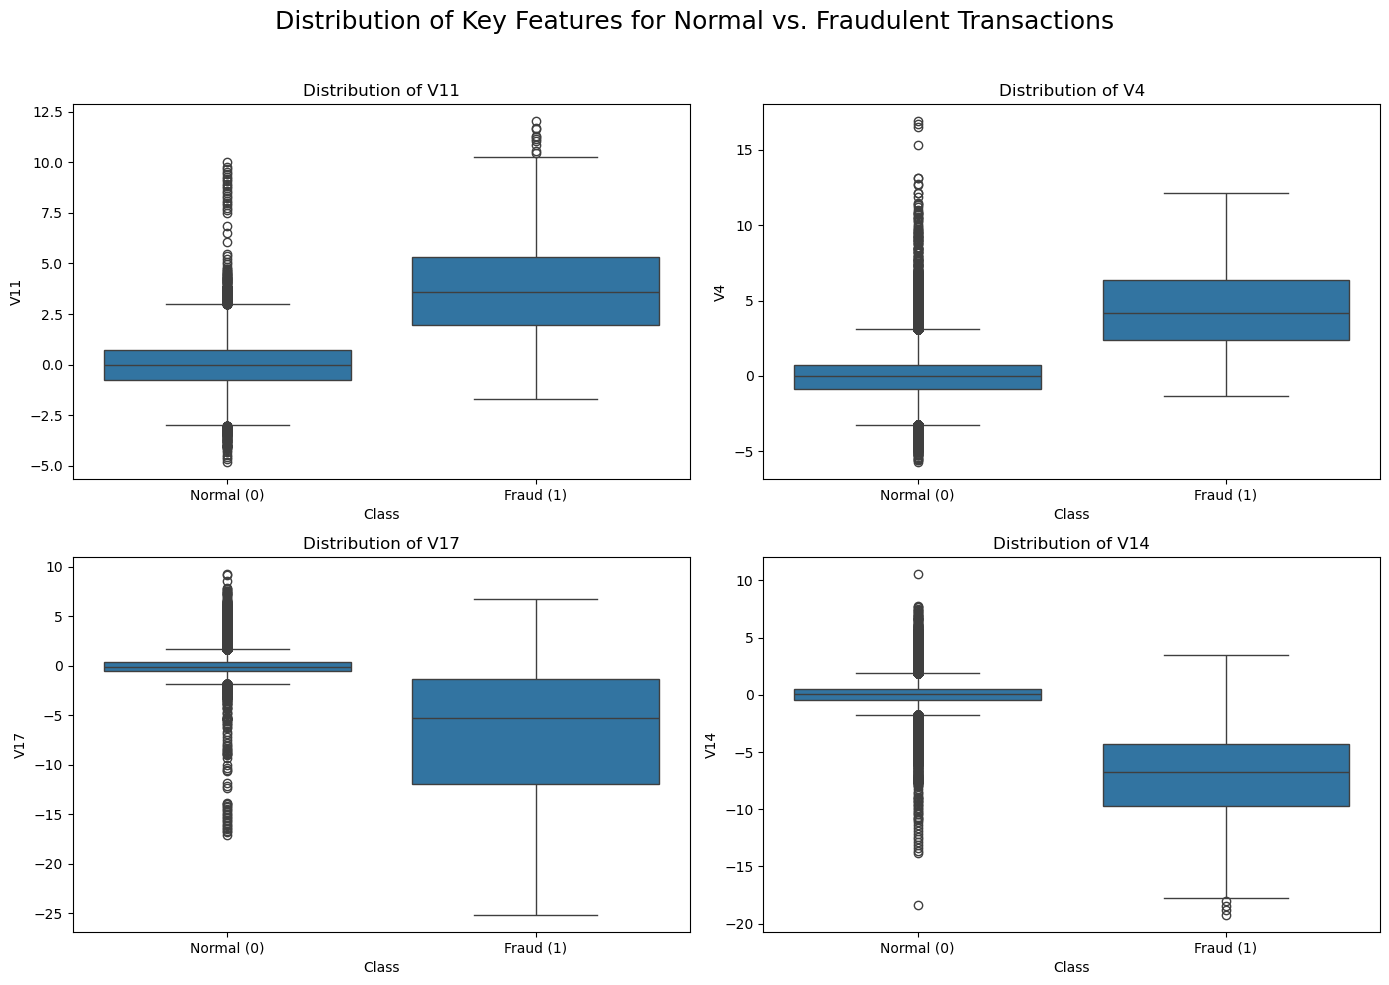


--- 3. Scatter Plot to Visualize Separation ---


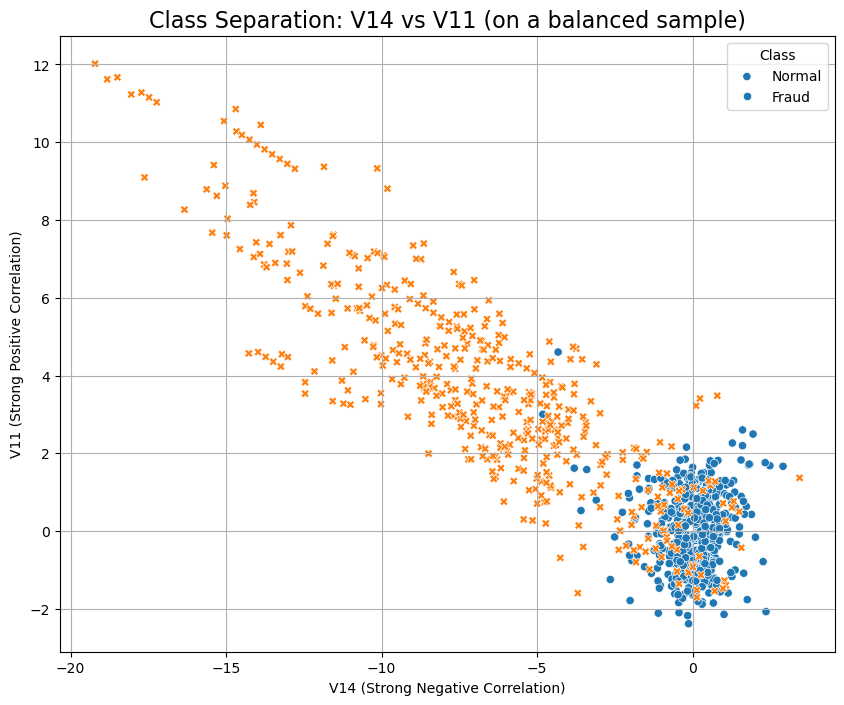

In [29]:
print("--- 1. Correlation Analysis ---")

corr_matrix = df.corr()

corr_class = corr_matrix['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=corr_class.values, y=corr_class.index, palette='vlag')
plt.title('Correlation of Features with the Fraud Class', fontsize=16)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')
plt.show()

print("Top 5 positive correlations with fraud:\n", corr_class.head(5))
print("\nTop 5 negative correlations with fraud:\n", corr_class.tail(5))

print("\n--- 2. Distribution of Key Features by Class ---")

features_to_plot = ['V11', 'V4', 'V17', 'V14']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Features for Normal vs. Fraudulent Transactions', fontsize=18)

for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.boxplot(x='Class', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xticklabels(['Normal (0)', 'Fraud (1)'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n--- 3. Scatter Plot to Visualize Separation ---")

# Separate the two classes
df_fraud = df[df['Class'] == 1]
df_normal = df[df['Class'] == 0]

df_normal_sample = df_normal.sample(n=len(df_fraud), random_state=42)
df_scatter = pd.concat([df_normal_sample, df_fraud])

plt.figure(figsize=(10, 8))
sns.scatterplot(x='V14', y='V11', hue='Class', data=df_scatter, style='Class')
plt.title('Class Separation: V14 vs V11 (on a balanced sample)', fontsize=16)
plt.xlabel('V14 (Strong Negative Correlation)')
plt.ylabel('V11 (Strong Positive Correlation)')
plt.legend(title='Class', labels=['Normal', 'Fraud'])
plt.grid(True)
plt.show()

Two clear groups of variables are visible: blue (positive correlations) and red (negative correlations). The longest bars indicate the strongest relationships.
- V11 and V4 are the most significant. When their values increase, the risk of fraud increases. A model will learn to be cautious with transactions that have high values for these variables.
- V17, V14, V12, and V10 are the strongest. Very low (strongly negative) values for these variables are strongly associated with fraud.

For the four selected variables, the distributions (the “boxes”) for normal and fraudulent transactions are drastically different, with almost no overlap.
- For V11 and V4, the “Fraud (1)” box is much higher than the “Normal (0)” box.
- For V17 and V14, the “Fraud (1)” box is much lower.

For the four selected variables, the distributions (the “boxes”) for normal and fraudulent transactions are drastically different, with almost no overlap.
- For V11 and V4, the “Fraud (1)” box is much higher than the “Normal (0)” box.
- For V17 and V14, the “Fraud (1)” box is much lower.

Orange points (“Fraud”) and blue points (“Normal”) are not randomly mixed; they form two distinct clusters.

The fraud cluster is clearly concentrated in the upper-left part of the plot (V14 very negative, V11 positive). 

--- Calculating and Visualizing the Full Correlation Matrix ---


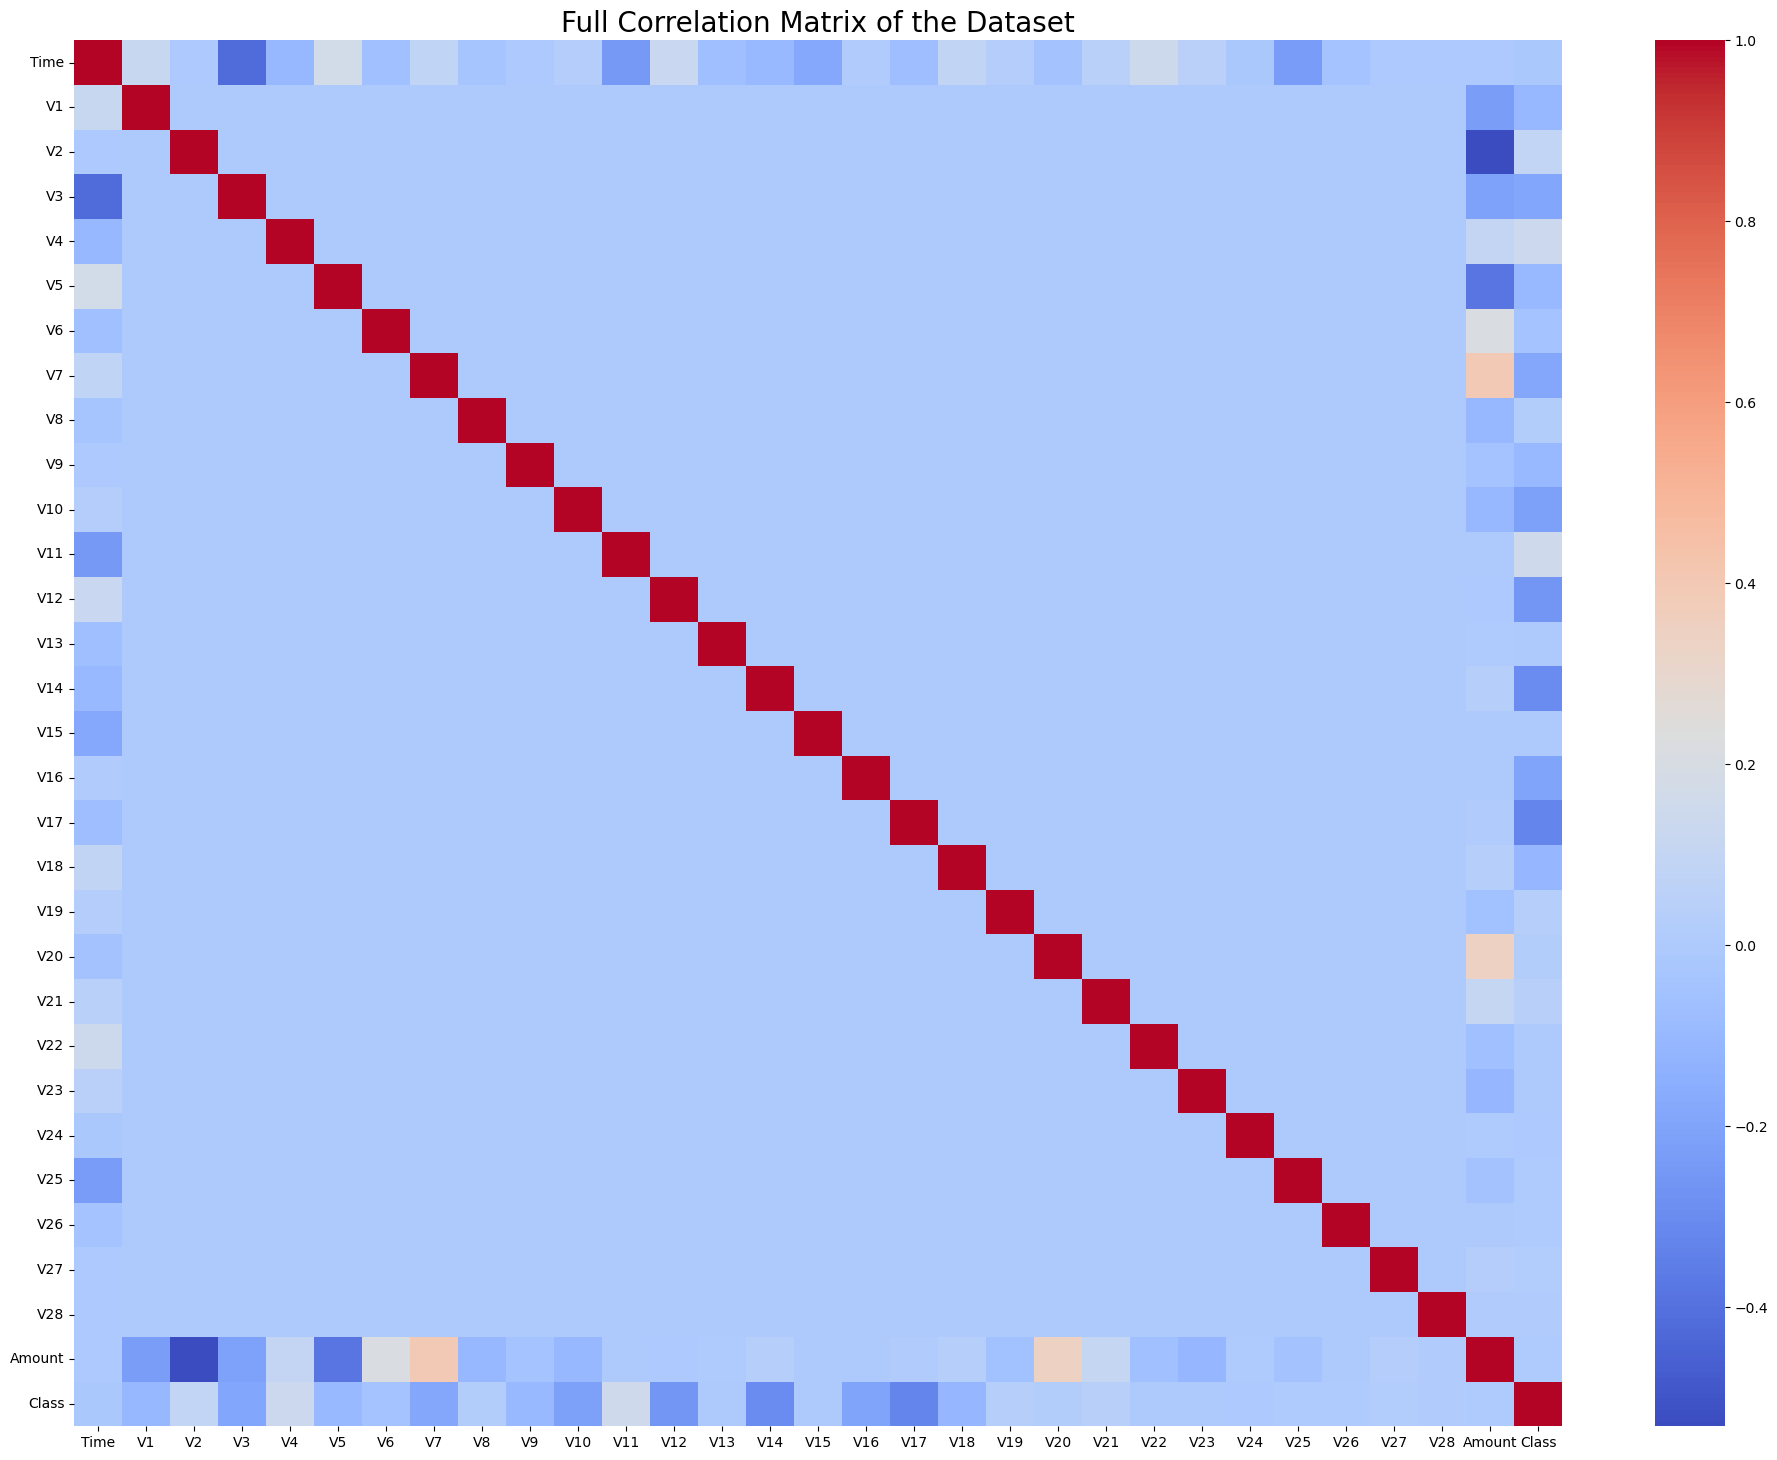

In [30]:
print("--- Calculating and Visualizing the Full Correlation Matrix ---")
corr_matrix_full = df.corr()
plt.figure(figsize=(24, 18)) 
sns.heatmap(corr_matrix_full, 
            cmap='coolwarm', 
            annot=False)    
plt.title('Full Correlation Matrix of the Dataset', fontsize=20)
plt.show()

The heatmap is dominated by three areas: the bright red diagonal, the large central light-blue/neutral square, and a few colored rows/columns on the edges.
- Large central blue/neutral square (V1 to V28) Confirms that the PCA worked. These variables are decorrelated from each other. 
- Edge rows/columns Visually show the correlations we analyzed earlier. The Class column (far right) shows the same color patterns (red for negative, blue for positive) as the first bar chart.

# Handling Class Imbalance

--- Class Distribution BEFORE Resampling ---
Class
0    227451
1       394
Name: count, dtype: int64

--- Applying Undersampling ---
New shape of X_train_under: (788, 32)
New class distribution (after Undersampling):
Class
0    394
1    394
Name: count, dtype: int64

--- Applying Oversampling (SMOTE) ---
New shape of X_train_smote: (454902, 32)
New class distribution (after SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


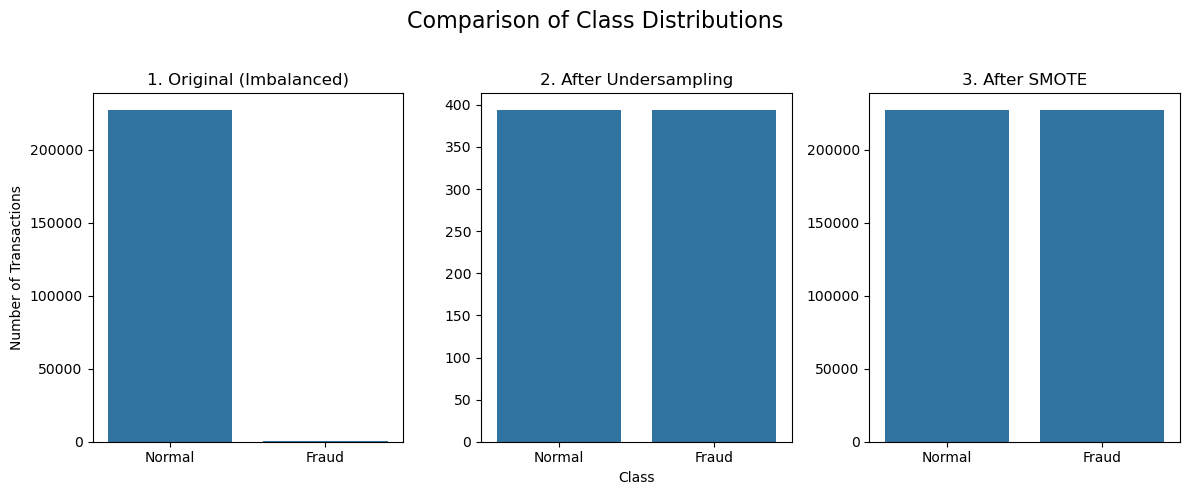

In [31]:
print("--- Class Distribution BEFORE Resampling ---")
original_counts = y_train.value_counts()
print(original_counts)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
sns.countplot(x=y_train).set_title('1. Original (Imbalanced)')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.xlabel('')
plt.ylabel('Number of Transactions')

print("\n--- Applying Undersampling ---")
rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("New shape of X_train_under:", X_train_under.shape)
print("New class distribution (after Undersampling):")
print(y_train_under.value_counts())

plt.subplot(1, 3, 2)
sns.countplot(x=y_train_under).set_title('2. After Undersampling')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.xlabel('Class')
plt.ylabel('')

print("\n--- Applying Oversampling (SMOTE) ---")
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("New shape of X_train_smote:", X_train_smote.shape)
print("New class distribution (after SMOTE):")
print(y_train_smote.value_counts())

plt.subplot(1, 3, 3)
sns.countplot(x=y_train_smote).set_title('3. After SMOTE')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.xlabel('')
plt.ylabel('')

plt.suptitle('Comparison of Class Distributions', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

- The first chart dramatically illustrates the core issue. The bar for “Normal” transactions is so tall that it completely overshadows the one for “Fraud” transactions, which is barely visible.
- The second chart shows a dramatic change. The two bars now have exactly the same height, indicating a perfect balance between the classes. The scale on the Y-axis shows that the total number of transactions is now very small (around 400).
- The third chart also shows a perfect balance with two bars of equal height. However, the scale on the Y-axis is enormous, indicating that the dataset has become very large.

# Logistic Regression

--- Training on data: Original Imbalanced ---

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



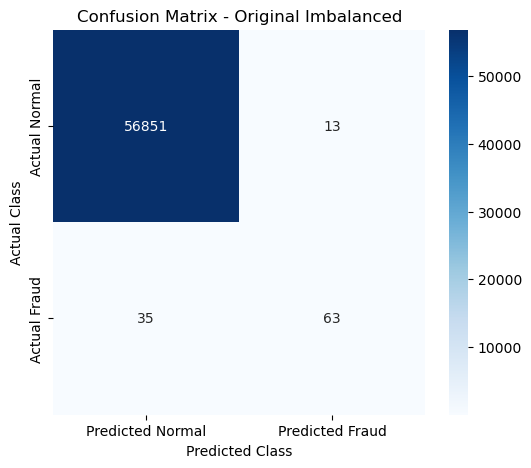

--------------------------------------------------

--- Training on data: Undersampled ---

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.96      0.98     56864
   Fraud (1)       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



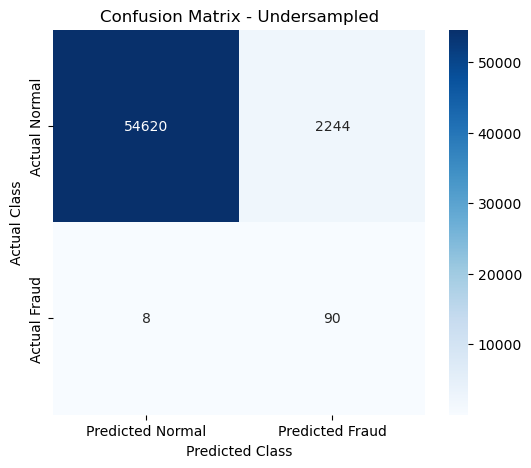

--------------------------------------------------

--- Training on data: Oversampled (SMOTE) ---

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.97      0.99     56864
   Fraud (1)       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



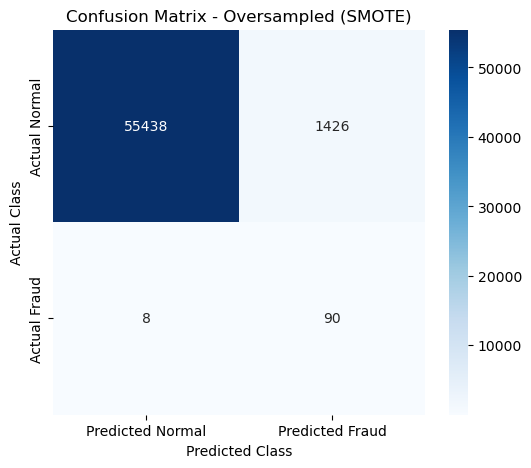

--------------------------------------------------


--- Performance Summary Table (Logistic Regression) ---
                       recall  precision  f1-score  accuracy
Original Imbalanced  0.642857   0.828947  0.724138  0.999157
Undersampled         0.918367   0.038560  0.074013  0.960465
Oversampled (SMOTE)  0.918367   0.059367  0.111524  0.974825


In [32]:
training_data = {
    "Original Imbalanced": (X_train, y_train),
    "Undersampled": (X_train_under, y_train_under),
    "Oversampled (SMOTE)": (X_train_smote, y_train_smote)
}

results = {}

for name, (X_t, y_t) in training_data.items():
    print(f"--- Training on data: {name} ---")
 
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_t, y_t)
  
    y_pred = model.predict(X_test)

    print("\nClassification Report:")
    report = classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fraud (1)'])
    print(report)
   
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'precision': report_dict['1']['precision'],
        'recall': report_dict['1']['recall'],        
        'f1-score': report_dict['1']['f1-score'],    
        'accuracy': accuracy_score(y_test, y_pred)
    }
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Normal', 'Predicted Fraud'], 
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()
    print("-" * 50 + "\n")

print("\n--- Performance Summary Table (Logistic Regression) ---")
results_df = pd.DataFrame(results).T
results_df = results_df[['recall', 'precision', 'f1-score', 'accuracy']]
print(results_df)

Original Imbalanced
- Recall = 0.64 (64%): The model detected 63 out of 98 actual fraud cases. This is a start, but it means it missed 35 (False Negatives), which is very dangerous for a bank.
- Precision = 0.83 (83%): This is a very high score! When the model predicted “Fraud,” it was correct 83% of the time. It generated only 13 false alarms (False Positives).

Undersampled
- Recall = 0.92 (92%): Spectacular! The model now detected 90 out of 98 actual fraud cases, missing only 8. From a detection standpoint, this is a huge success.
- Precision = 0.04 (4%): Catastrophic. To catch these 90 frauds, the model generated 2,244 false alarms (False Positives). This means that 96% of the fraud alerts are false.

SMOTE
- Recall = 0.92 (92%): Same as the undersampled model, an excellent score. It also detected 90 out of 98 fraud cases, missing only 8.
- Precision = 0.06 (6%): Still very low, but better than the undersampled model. To find the 90 frauds, it generated 1,426 false alarms. That’s a lot, but it’s 818 fewer false alerts than the previous model for the same detection level!

# Random Forest

--- Training Random Forest on data: Original Imbalanced ---
Training time: 36.53 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



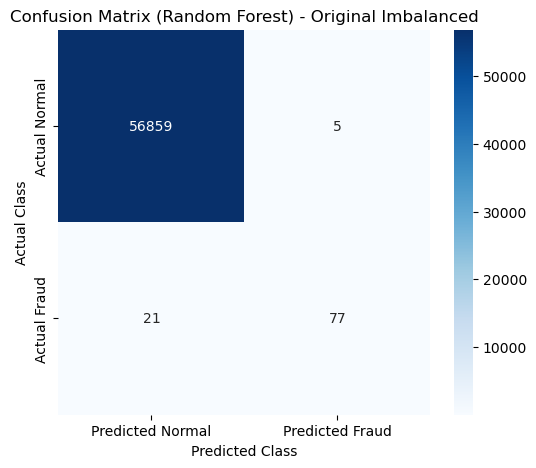

--------------------------------------------------

--- Training Random Forest on data: Undersampled ---
Training time: 0.20 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.96      0.98     56864
   Fraud (1)       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



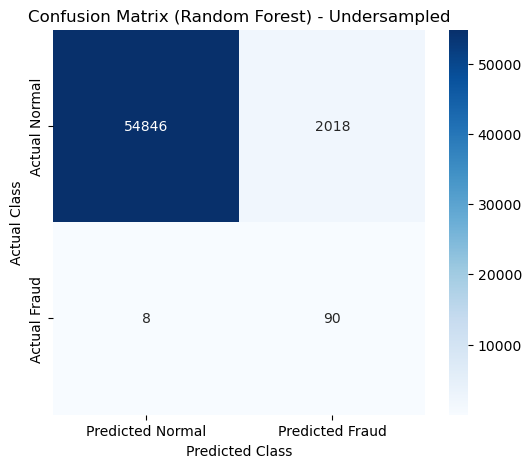

--------------------------------------------------

--- Training Random Forest on data: Oversampled (SMOTE) ---
Training time: 56.17 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



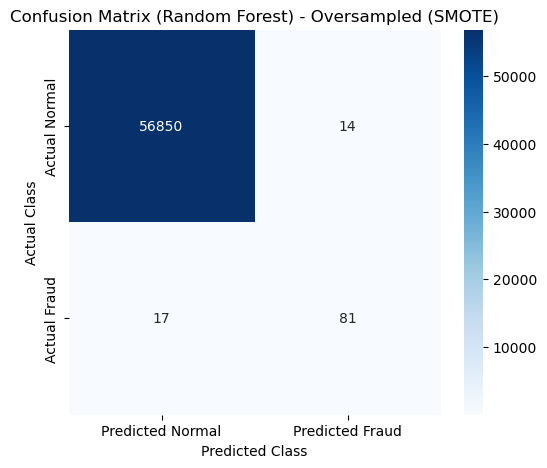

--------------------------------------------------


--- Performance Summary Table (Random Forest) ---
                       recall  precision  f1-score  accuracy
Original Imbalanced  0.785714   0.939024  0.855556  0.999544
Undersampled         0.918367   0.042694  0.081596  0.964432
Oversampled (SMOTE)  0.826531   0.852632  0.839378  0.999456


In [33]:
results_rf = {} 

for name, (X_t, y_t) in training_data.items():
    print(f"--- Training Random Forest on data: {name} ---")
    start_time = time.time()
    
    model_rf = RandomForestClassifier(random_state=42, n_jobs=-1) 
    model_rf.fit(X_t, y_t)
    
    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

    y_pred_rf = model_rf.predict(X_test)
    
    print("\nClassification Report:")
    report_rf = classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Fraud (1)'])
    print(report_rf)
  
    report_dict_rf = classification_report(y_test, y_pred_rf, output_dict=True)
    results_rf[name] = {
        'precision': report_dict_rf['1']['precision'],
        'recall': report_dict_rf['1']['recall'],
        'f1-score': report_dict_rf['1']['f1-score'],
        'accuracy': accuracy_score(y_test, y_pred_rf)
    }
 
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Normal', 'Predicted Fraud'], 
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f'Confusion Matrix (Random Forest) - {name}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()
    print("-" * 50 + "\n")

print("\n--- Performance Summary Table (Random Forest) ---")
results_rf_df = pd.DataFrame(results_rf).T
results_rf_df = results_rf_df[['recall', 'precision', 'f1-score', 'accuracy']]
print(results_rf_df)

Original Imbalanced 
- Recall = 0.79 (79%): It detected 77 out of 98 fraud cases. This is a significant improvement over the 64% achieved by Logistic Regression.
- Precision = 0.94 (94%): An incredible precision! There are only 5 false alarms.

Undersampled
- Recall = 0.92 (92%): It detects 90 out of 98 fraud cases, exactly like Logistic Regression.
- Precision = 0.04 (4%): Still catastrophic. It generates 2,018 false alarms.

SMOTE
- Recall = 0.83 (83%): The model detected 81 out of 98 fraud cases. This is lower than the 92% recall we had with Logistic Regression on the same data!
- Precision = 0.85 (85%): A spectacular improvement! Precision increased from 6% (with Logistic Regression) to 85%. The number of false alarms dropped from 1,426 to just 14!

# XGBoost

--- Training XGBoost on data: Original Imbalanced ---


c:\Users\zargu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:22:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time: 1.66 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



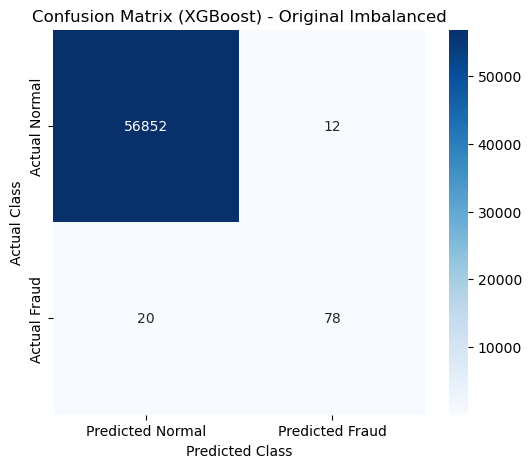

--------------------------------------------------

--- Training XGBoost on data: Undersampled ---
Training time: 0.09 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.98     56864
   Fraud (1)       0.03      0.92      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.95      0.97     56962



c:\Users\zargu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:22:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


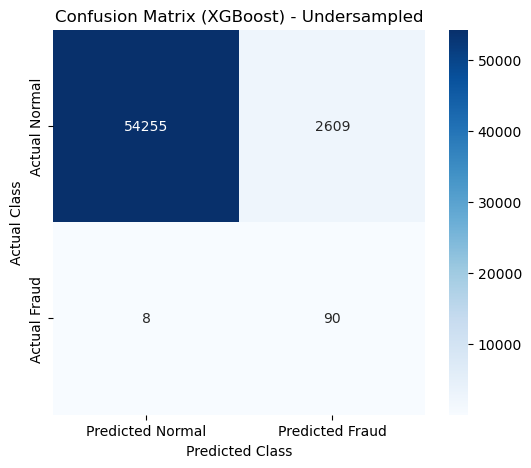

--------------------------------------------------

--- Training XGBoost on data: Oversampled (SMOTE) ---


c:\Users\zargu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:22:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time: 3.10 seconds

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.74      0.88      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



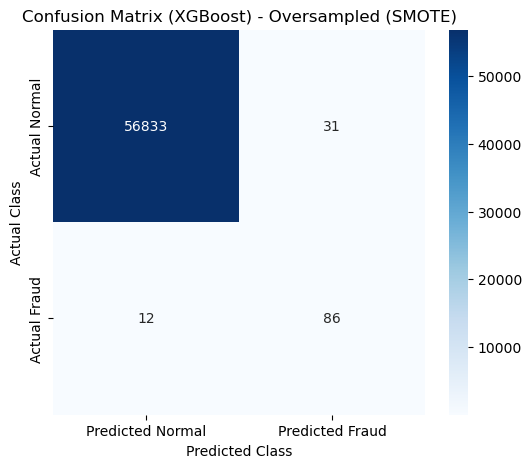

--------------------------------------------------


--- Performance Summary Table (XGBoost) ---
                       recall  precision  f1-score  accuracy
Original Imbalanced  0.795918   0.866667  0.829787  0.999438
Undersampled         0.918367   0.033346  0.064355  0.954057
Oversampled (SMOTE)  0.877551   0.735043  0.800000  0.999245


In [34]:
results_xgb = {} 

for name, (X_t, y_t) in training_data.items():
    print(f"--- Training XGBoost on data: {name} ---")
    start_time = time.time()

    model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

    model_xgb.fit(X_t.values, y_t.values)
    
    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

    y_pred_xgb = model_xgb.predict(X_test.values)

    print("\nClassification Report:")
    report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Normal (0)', 'Fraud (1)'])
    print(report_xgb)

    report_dict_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
    results_xgb[name] = {
        'precision': report_dict_xgb['1']['precision'],
        'recall': report_dict_xgb['1']['recall'],
        'f1-score': report_dict_xgb['1']['f1-score'],
        'accuracy': accuracy_score(y_test, y_pred_xgb)
    }
  
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Normal', 'Predicted Fraud'], 
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f'Confusion Matrix (XGBoost) - {name}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()
    print("-" * 50 + "\n")

print("\n--- Performance Summary Table (XGBoost) ---")
results_xgb_df = pd.DataFrame(results_xgb).T
results_xgb_df = results_xgb_df[['recall', 'precision', 'f1-score', 'accuracy']]
print(results_xgb_df)

Original Imbalanced
- Recall = 0.80 (80%): Detected 78 out of 98 fraud cases. This is very similar to the Random Forest (77).
- Precision = 0.87 (87%): Only 12 false alarms. Excellent precision—slightly lower than the Random Forest but still very strong.

Undersampled  
- Recall = 0.92 (92%): Detected 90 fraud cases.
- Precision = 0.03 (3%): Generated 2,609 false alarms.

Oversampled (SMOTE)
- Recall = 0.88 (88%): Detected 86 out of 98 fraud cases. This is an excellent detection score! It missed only 12 frauds.
- Precision = 0.74 (74%): Generated 31 false alarms. This is not as good as the 14 from the Random Forest, but vastly better than the 1,426 from Logistic Regression.

# Visual Evaluation and Final Comparison

Training final models on SMOTE data...


c:\Users\zargu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Logistic Regression trained.


c:\Users\zargu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Random Forest trained.


c:\Users\zargu\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:26:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained.

Calculating ROC curves...


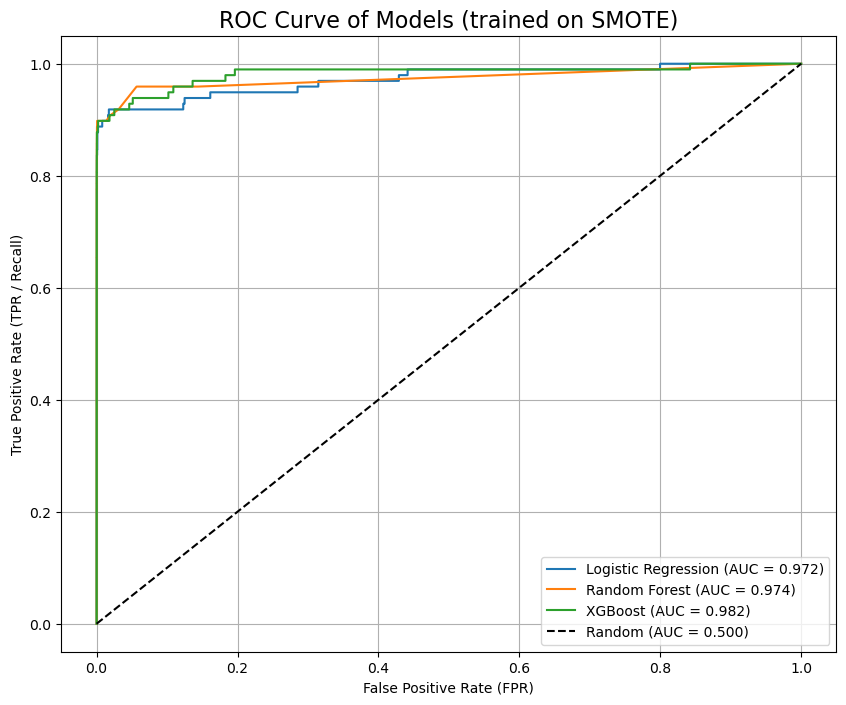


Calculating Precision-Recall curves...


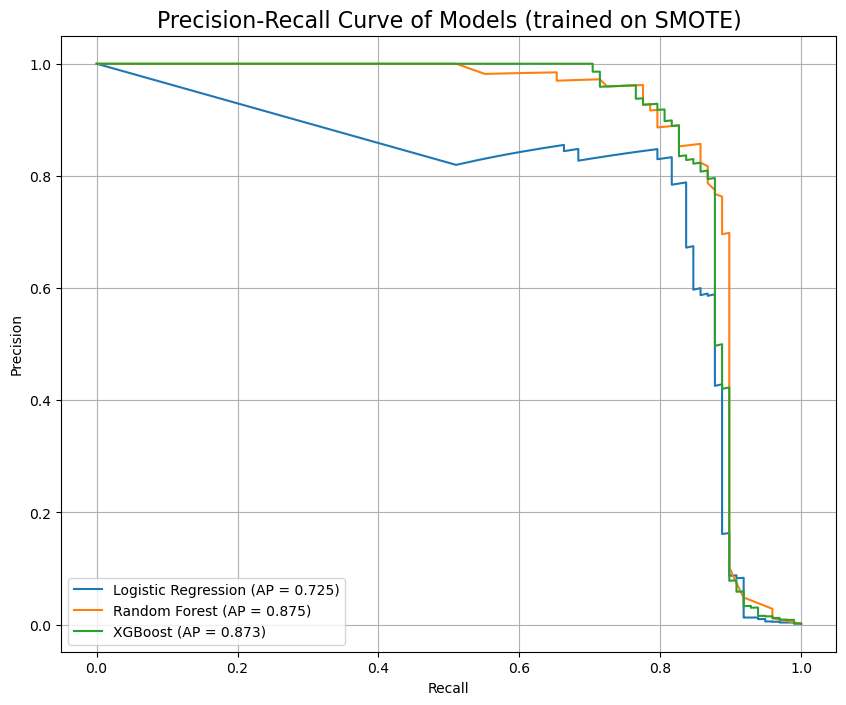

In [35]:
print("Training final models on SMOTE data...")

lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_proba_lr = lr_smote.predict_proba(X_test.values)[:, 1] # Probability for class 1 (fraud)
print("Logistic Regression trained.")

rf_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_proba_rf = rf_smote.predict_proba(X_test.values)[:, 1]
print("Random Forest trained.")

xgb_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_smote.fit(X_train_smote.values, y_train_smote.values)
y_pred_proba_xgb = xgb_smote.predict_proba(X_test.values)[:, 1]
print("XGBoost trained.")

print("\nCalculating ROC curves...")

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.title('ROC Curve of Models (trained on SMOTE)', fontsize=16)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.legend()
plt.grid(True)
plt.show()

print("\nCalculating Precision-Recall curves...")

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
ap_lr = average_precision_score(y_test, y_pred_proba_lr)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
ap_rf = average_precision_score(y_test, y_pred_proba_rf)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 8))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.3f})')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {ap_xgb:.3f})')
plt.title('Precision-Recall Curve of Models (trained on SMOTE)', fontsize=16)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

The three curves are “crammed” in the upper-left corner, and the three AUC (Area Under the Curve) scores are extremely high: 0.972, 0.974, and 0.982.

- Logistic Regression (AP = 0.725): This is the lowest curve. It maintains high precision only for very low recall (when it detects few frauds). As soon as it tries to detect more frauds (recall increases), its precision drops drastically.
- XGBoost (AP = 0.873): The green curve is significantly higher. It maintains very high precision (close to 1.0) up to a recall of about 0.8. This means XGBoost can detect 80% of frauds while keeping almost perfect precision! Precision then starts to drop, but it remains higher than Logistic Regression.
- Random Forest (AP = 0.875): The orange curve is almost identical to XGBoost, even slightly above in some areas. Its Average Precision (AP) score is marginally higher.